# YOLO Object Detection — Training

This notebook defines the YOLO loss function and runs the training loop. It imports the model and dataset from `model.ipynb` and `data.ipynb`.

## YOLO Loss Function

Our model outputs **170 values per grid cell** — 2 boxes × 85 values each:

```
[objectness, x, y, w, h, class_0 ... class_79]  ×  2 anchors
```

The total loss has four components:

| Component | Loss type | Applied to |
|---|---|---|
| **Objectness** | BCE | Cells with an object — was the model confident an object was there? |
| **No-object** | BCE | Background cells (weighted lower with λ=0.5 since they vastly outnumber object cells) |
| **Box (xy)** | BCE | Only cells with an object — centre offset within the cell |
| **Box (wh)** | MSE on log scale | Only cells with an object — width/height vs anchor |
| **Class** | BCE | Only cells with an object — which of 80 classes? |

The **object mask** is key — box and class losses are only applied to cells that actually contain an object, preventing the model from being penalised for not predicting boxes everywhere.

**λ weights** let you control how much each part matters. Each loss term is normalized **per active cell** (i.e. divided by the number of positive cells for obj/xy/wh/cls, or by the number of background cells for noobj), so all components live on the same scale. We therefore keep `λ_xy = λ_wh = λ_cls = λ_obj = 1` and only down-weight noobj with `λ_noobj = 0.5`. The classic YOLOv1 values (`λ_xy = λ_wh = 5`) assume summed-not-averaged losses and would make localisation dominate the gradient under per-cell normalization.

In [15]:
import torch

### Draft Loss Functions

These standalone functions show how each loss component works in isolation. The actual training uses `total_loss` below, which combines them all.

In [16]:
# objectness loss
'''
Because this is either 1 (there is an object here) or 0 (there is no object here) we should use binary cross entropy BCE to measure the loss. 
takes in (2,13,13) since each cell has 2 objectness values; 1 for each box and there is 13x13 cells outputs (2x13x13)
'''

def object_loss(predicted_objectness, target_objectness):
    return torch.nn.BCEWithLogitsLoss(predicted_objectness, target_objectness)

In [17]:
# box coordinates loss
'''
calcualted for cells that have an object. It compares predicted box coordinates agains the target box coordinates                                                                                                                                                 
  input:  predicted_xy [2, 2, 13, 13]
          predicted_wh [2, 2, 13, 13]                                                                                                                 
          target_xy    [2, 2, 13, 13]
          target_wh    [2, 2, 13, 13]                                                                                                                 
          anchor       [2]  e.g. tensor([0.28, 0.22])
  output: scalar loss value                                                                                                                           
  '''  

def box_loss(predicted_xy, predicted_wh, target_xy, target_wh, anchor):
  loss_xy = torch.nn.BCEWithLogitsLoss(reduction='none')(predicted_xy, target_xy)                                                                                 
  loss_wh = torch.nn.MSELoss(reduction='none')(predicted_wh, torch.log(target_wh / anchor + 1e-16))
  return loss_xy , loss_wh  


In [18]:
# class loss
'''
Only calculated for cells that have an object. Compares predicted class scores against the true class:                                                                                               
  target = one-hot vector [0, 0, 1, 0, ...] ← 1 at the correct class index
  loss = BCE(sigmoid(pred_classes), target)  
  takes a input shape (2, 80, 13,13)
'''

def class_loss(predicted_classes, target_classes):
  loss_fn = torch.nn.Softmax()
  return loss_fn(predicted_classes, target_classes)


### Total Loss

Combines all components into a single scalar. For each image:
1. Parse the model's `[170, 13, 13]` output into objectness, xy, wh, and class tensors
2. Build target tensors by mapping each ground-truth label to its grid cell and best-matching anchor
3. Compute masked losses — box/class losses only where `obj_mask == 1`
4. Return the weighted sum and a breakdown dict for monitoring

In [19]:
# total loss
'''
  loss = λ_obj  * objectness_loss
       + λ_noobj * noobj_loss      ← background cells weighted separately
       + λ_box  * box_loss
       + λ_class * class_loss

  Each term is normalized per active cell (not over the full 2×13×13 grid),
  so λ weights are balanced at 1 — down-weighting only noobj since background
  cells vastly outnumber object cells.
  takes inputs predictions (170, 13,13) labels (5,)
'''

GRID_SIZE   = 13
NUM_CLASSES = 80
anchors     = torch.tensor([[0.28, 0.22], [0.38, 0.48]])

λ_obj   = 1.0
λ_noobj = 0.5
λ_xy    = 1.0
λ_wh    = 1.0
λ_cls   = 1.0

def total_loss(predictions, labels):
    dev = predictions.device

    # --- Extract predictions ---
    pred_obj = torch.stack([predictions[0,  :, :], predictions[85, :, :]])     # [2, 13, 13]
    pred_xy  = torch.stack([predictions[1:3,   :, :], predictions[86:88, :, :]])  # [2, 2, 13, 13]
    pred_wh  = torch.stack([predictions[3:5,   :, :], predictions[88:90, :, :]])  # [2, 2, 13, 13]
    pred_cls = torch.stack([predictions[5:85,   :, :], predictions[90:170, :, :]]) # [2, 80, 13, 13]

    # --- Build targets on same device as predictions ---
    target_obj = torch.zeros(2, GRID_SIZE, GRID_SIZE, device=dev)
    target_xy  = torch.zeros(2, 2, GRID_SIZE, GRID_SIZE, device=dev)
    target_wh  = torch.zeros(2, 2, GRID_SIZE, GRID_SIZE, device=dev)
    target_cls = torch.zeros(2, NUM_CLASSES, GRID_SIZE, GRID_SIZE, device=dev)
    obj_mask   = torch.zeros(2, GRID_SIZE, GRID_SIZE, device=dev)

    for label in labels:
        category_id, cx, cy, w, h = label

        grid_x = min(int(cx * GRID_SIZE), GRID_SIZE - 1)
        grid_y = min(int(cy * GRID_SIZE), GRID_SIZE - 1)

        ious = []
        for anchor in anchors:
            inter = min(w.item(), anchor[0].item()) * min(h.item(), anchor[1].item())
            union = w * h + anchor[0] * anchor[1] - inter
            ious.append(inter / union)
        best = int(torch.tensor(ious).argmax())

        tx = cx * GRID_SIZE - grid_x
        ty = cy * GRID_SIZE - grid_y

        target_obj[best, grid_y, grid_x]    = 1.0
        target_xy [best, :, grid_y, grid_x] = torch.tensor([tx, ty], device=dev)
        target_wh [best, :, grid_y, grid_x] = torch.tensor([w, h], device=dev)
        target_cls[best, int(category_id), grid_y, grid_x] = 1.0
        obj_mask  [best, grid_y, grid_x]    = 1.0

    noobj_mask = 1 - obj_mask

    # --- Calculate losses ---
    # Normalize each term by the number of cells that actually contribute.
    # Using .mean() over the whole [2,13,13] grid dilutes the object-cell signal
    # ~300× (only a handful of cells are positive out of 338) and lets the
    # model settle into a "predict no object everywhere" local minimum.
    bce = torch.nn.BCEWithLogitsLoss(reduction='none')
    mse = torch.nn.MSELoss(reduction='none')

    num_obj   = obj_mask.sum().clamp(min=1)
    num_noobj = noobj_mask.sum().clamp(min=1)

    loss_obj   = (bce(pred_obj, target_obj) * obj_mask).sum() / num_obj
    loss_noobj = (bce(pred_obj, target_obj) * noobj_mask).sum() / num_noobj
    loss_xy    = (bce(pred_xy, target_xy) * obj_mask.unsqueeze(1)).sum() / num_obj
    loss_wh    = (mse(pred_wh, torch.log(target_wh / anchors.view(2,2,1,1).to(dev) + 1e-16))
                  * obj_mask.unsqueeze(1)).sum() / num_obj
    loss_cls   = (bce(pred_cls, target_cls) * obj_mask.unsqueeze(1)).sum() / num_obj

    loss = (λ_obj   * loss_obj
          + λ_noobj * loss_noobj
          + λ_xy    * loss_xy
          + λ_wh    * loss_wh
          + λ_cls   * loss_cls)

    return loss, {
        'obj':   loss_obj.item(),
        'noobj': loss_noobj.item(),
        'xy':    loss_xy.item(),
        'wh':    loss_wh.item(),
        'cls':   loss_cls.item(),
    }

## Training

The training loop:
1. Loads the dataset and model from the other notebooks
2. Runs Adam optimiser with `lr=0.001`
3. For each image: forward pass → compute loss → backprop → update weights
4. Saves `model1.pth` after every epoch so you can stop at any time

### Imports

Load the dataset and model architecture from the other notebooks. `%run` executes the notebook in the current kernel, making all defined variables available here.

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
PyTorch is using mps.
=== Keys ===
['info', 'licenses', 'images', 'annotations', 'categories']

=== Info ===
{ 'contributor': 'COCO Consortium',
  'date_created': '2017/09/01',
  'description': 'COCO 2017 Dataset',
  'url': 'http://cocodataset.org',
  'version': '1.0',
  'year': 2017}

=== Sample Image ===
{ 'coco_url': 'http://images.cocodataset.org/train2017/000000391895.jpg',
  'date_captured': '2013-11-14 11:18:45',
  'file_name': '000000391895.jpg',
  'flickr_url': 'http://farm9.staticflickr.com/8186/8119368305_4e622c8349_z.jpg',
  'height': 360,
  'id': 391895,
  'license': 3,
  'width': 640}

=== Sample Annotation ===
{ 'area': 2765.1486500000005,
  'bbox': [199.84, 200.46, 77.71, 70.88],
  'category_id': 58,
  'id': 15

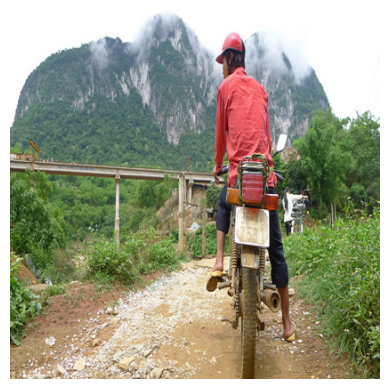

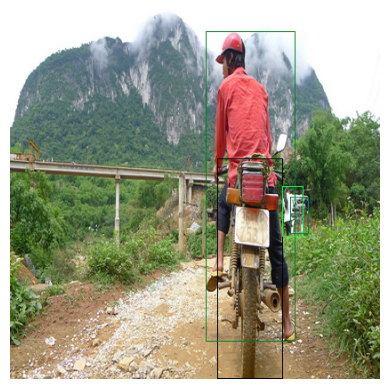

Model(
  (layers): ModuleList(
    (0): Conv(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batch_norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (Silu): SiLU()
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batch_norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (Silu): SiLU()
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batch_norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (Silu): SiLU()
    )
    (5): Conv(
      (conv): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
      (batch_norm): BatchNorm2d(64, eps=1e-05, momentu

In [20]:
# --- this gets the dataset and model from the other notebooks ---
%pip install nbformat -q
%run data.ipynb
%run model.ipynb 

### Training Loop

- `batch_size=16` — multiple images per step (BatchNorm works better with real batches, and gradients are smoother)
- `num_workers=4` — parallel data-loading workers feed the GPU so it doesn't wait on disk
- `collate_fn` — images stack cleanly into `[B, 3, 416, 416]`, but labels have variable object counts so we keep them as a list of `[N_i, 5]` tensors
- `predictions[i]` — loss is still computed per-image (`[170, 13, 13]`) and summed across the batch, then backpropped once per step

**Validation** — each epoch on train2017 is ~7400 steps, so we:
- Print a running training loss every `LOG_EVERY` steps so you can watch it learn in real time
- Run the full val2017 set at the end of each epoch under `model.eval()` + `torch.no_grad()` and report the validation loss. A growing gap between train and val loss is the classic overfitting signal.

In [21]:
# --- building our training --- 
import time
from dataset import coco_dataset, yolo_collate  # importable so DataLoader workers can pickle them

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model  = model.to(device)

BATCH_SIZE  = 16
NUM_WORKERS = 4
LOG_EVERY   = 50   # print running train loss every N steps

# full train2017 set (~118k images)
train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=yolo_collate,
    persistent_workers=True,
)

# val2017 for validation (~5k images, held out from training)
val_dataset = coco_dataset(
    images_path="val2017",
    labels_path="annotations/instances_val2017.json",
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=yolo_collate,
    persistent_workers=True,
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


def run_validation():
    model.eval()
    total, steps = 0.0, 0
    breakdown_sum = {'obj': 0.0, 'noobj': 0.0, 'xy': 0.0, 'wh': 0.0, 'cls': 0.0}
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            preds  = model(images)
            for i in range(preds.shape[0]):
                loss_i, bd = total_loss(preds[i], labels[i].to(device))
                total += loss_i.item()
                for k in breakdown_sum:
                    breakdown_sum[k] += bd[k]
                steps += 1
    model.train()
    return total / steps, {k: v / steps for k, v in breakdown_sum.items()}


for epoch in range(100):
    model.train()
    epoch_loss, num_steps = 0.0, 0
    running_loss, running_steps = 0.0, 0
    t0 = time.time()

    for images, labels in train_loader:
        optimizer.zero_grad()

        images      = images.to(device)
        predictions = model(images)   # [B, 170, 13, 13]

        batch_loss = 0.0
        for i in range(predictions.shape[0]):
            loss_i, breakdown = total_loss(predictions[i], labels[i].to(device))
            batch_loss = batch_loss + loss_i
        batch_loss = batch_loss / predictions.shape[0]

        batch_loss.backward()
        optimizer.step()

        epoch_loss    += batch_loss.item()
        running_loss  += batch_loss.item()
        num_steps     += 1
        running_steps += 1

    train_avg = epoch_loss / num_steps
    val_avg, val_bd = run_validation()
    print(f"Epoch {epoch} | train {train_avg:.4f} | val {val_avg:.4f} | val breakdown {val_bd}")
    torch.save(model.state_dict(), 'model1.pth')  # save after every epoch

Epoch 0 | train 6.8310 | val 6.2642 | val breakdown {'obj': 0.25566878914984553, 'noobj': 0.582181691916287, 'xy': 1.3399668382525445, 'wh': 0.763989347846096, 'cls': 3.613441956442711}
Epoch 1 | train 5.7452 | val 5.4192 | val breakdown {'obj': 0.20488834514810006, 'noobj': 0.5503290608398617, 'xy': 1.3220218260765075, 'wh': 0.5973762629912962, 'cls': 3.0197154226597864}
Epoch 2 | train 5.2056 | val 4.9703 | val breakdown {'obj': 0.17893556087288306, 'noobj': 0.523797361843288, 'xy': 1.3070198794603347, 'wh': 0.5274504219033362, 'cls': 2.6950383819527457}
Epoch 3 | train 4.8208 | val 4.6940 | val breakdown {'obj': 0.17135758729691733, 'noobj': 0.49294242400228977, 'xy': 1.2976998806238174, 'wh': 0.4977081693868458, 'cls': 2.4807354004228155}
Epoch 4 | train 4.5198 | val 4.4826 | val breakdown {'obj': 0.1762756539455615, 'noobj': 0.4603278839945793, 'xy': 1.2922202621340753, 'wh': 0.4628492613710456, 'cls': 2.32105644869627}
Epoch 5 | train 4.2704 | val 4.4230 | val breakdown {'obj': 0

KeyboardInterrupt: 

Epoch 0 | train 6.8310 | val 6.2642 | val breakdown {'obj': 0.25566878914984553, 'noobj': 0.582181691916287, 'xy': 1.3399668382525445, 'wh': 0.763989347846096, 'cls': 3.613441956442711}
Epoch 1 | train 5.7452 | val 5.4192 | val breakdown {'obj': 0.20488834514810006, 'noobj': 0.5503290608398617, 'xy': 1.3220218260765075, 'wh': 0.5973762629912962, 'cls': 3.0197154226597864}
Epoch 2 | train 5.2056 | val 4.9703 | val breakdown {'obj': 0.17893556087288306, 'noobj': 0.523797361843288, 'xy': 1.3070198794603347, 'wh': 0.5274504219033362, 'cls': 2.6950383819527457}
Epoch 3 | train 4.8208 | val 4.6940 | val breakdown {'obj': 0.17135758729691733, 'noobj': 0.49294242400228977, 'xy': 1.2976998806238174, 'wh': 0.4977081693868458, 'cls': 2.4807354004228155}
Epoch 4 | train 4.5198 | val 4.4826 | val breakdown {'obj': 0.1762756539455615, 'noobj': 0.4603278839945793, 'xy': 1.2922202621340753, 'wh': 0.4628492613710456, 'cls': 2.32105644869627}
Epoch 5 | train 4.2704 | val 4.4230 | val breakdown {'obj': 0.15768810063956626, 'noobj': 0.47924897208064793, 'xy': 1.287010115289688, 'wh': 0.46239841284984434, 'cls': 2.2762472363784267}
Epoch 6 | train 4.0613 | val 4.3070 | val breakdown {'obj': 0.15361590733634803, 'noobj': 0.46746058436110616, 'xy': 1.2832898339748382, 'wh': 0.44499252001557327, 'cls': 2.1913665374481592}
Epoch 7 | train 3.8463 | val 4.2309 | val breakdown {'obj': 0.1666551029539667, 'noobj': 0.42701015501990913, 'xy': 1.2808061896681786, 'wh': 0.4308689056369753, 'cls': 2.1390660554069183}
Epoch 8 | train 3.6428 | val 4.2058 | val breakdown {'obj': 0.17641956635951464, 'noobj': 0.40669708609282973, 'xy': 1.2807591175615787, 'wh': 0.4316699650650684, 'cls': 2.113555423486684}
Epoch 9 | train 3.4398 | val 4.2498 | val breakdown {'obj': 0.17312321914489676, 'noobj': 0.4103020998902619, 'xy': 1.278744832456112, 'wh': 0.43443700212257824, 'cls': 2.158367265983866}
Epoch 10 | train 3.2425 | val 4.3058 | val breakdown {'obj': 0.16080024440212182, 'noobj': 0.4267262848258018, 'xy': 1.2782345665812493, 'wh': 0.4294620729912116, 'cls': 2.2239847495353118}
Epoch 11 | train 3.0576 | val 4.3653 | val breakdown {'obj': 0.1809780469754006, 'noobj': 0.39020114761479197, 'xy': 1.2773378128230573, 'wh': 0.4211076372723066, 'cls': 2.290741000846836}
Epoch 12 | train 2.8874 | val 4.5312 | val breakdown {'obj': 0.19710829595527968, 'noobj': 0.37437382089458404, 'xy': 1.2781349629282952, 'wh': 0.43031662218188577, 'cls': 2.4384413864769106}
Epoch 13 | train 2.7271 | val 4.6081 | val breakdown {'obj': 0.18877894590729183, 'noobj': 0.38745438539460303, 'xy': 1.2807488728523255, 'wh': 0.428889555047889, 'cls': 2.515977878327155}
Epoch 14 | train 2.5861 | val 4.8226 | val breakdown {'obj': 0.2030328219140485, 'noobj': 0.3713217943176627, 'xy': 1.2816830099225045, 'wh': 0.43991642894704125, 'cls': 2.7122782755280563}
Epoch 15 | train 2.4633 | val 5.0225 | val breakdown {'obj': 0.22005159238573205, 'noobj': 0.3713238741196692, 'xy': 1.2835950305938721, 'wh': 0.43885757170352446, 'cls': 2.8943255154488163}
Epoch 16 | train 2.3541 | val 5.1970 | val breakdown {'obj': 0.22352934450570155, 'noobj': 0.3598264766842127, 'xy': 1.2876976340889932, 'wh': 0.4343115646815044, 'cls': 3.071572810376975}
Epoch 17 | train 2.2547 | val 5.3953 | val breakdown {'obj': 0.24693916183499695, 'noobj': 0.3445834807638079, 'xy': 1.2863401068270206, 'wh': 0.4374088573770625, 'cls': 3.252359230355024}
Epoch 18 | train 2.1677 | val 5.4510 | val breakdown {'obj': 0.2580296915034529, 'noobj': 0.33184281327053905, 'xy': 1.2893215701580047, 'wh': 0.4411501940100754, 'cls': 3.2965478932857035}
Epoch 19 | train 2.0957 | val 5.7493 | val breakdown {'obj': 0.27968275873755216, 'noobj': 0.33304642217718067, 'xy': 1.2914377341151237, 'wh': 0.44378627823133426, 'cls': 3.5678535437486136}
Epoch 20 | train 2.0274 | val 5.9029 | val breakdown {'obj': 0.2990264621741993, 'noobj': 0.3141578734114766, 'xy': 1.2923740366578103, 'wh': 0.4371087761058967, 'cls': 3.717278982175129}
Epoch 21 | train 1.9741 | val 5.9701 | val breakdown {'obj': 0.30790257220618916, 'noobj': 0.3172234412096441, 'xy': 1.2941447870612144, 'wh': 0.4396484389508027, 'cls': 3.769768741800317}


### Save Model

Run this cell to manually save the model at any point. The training loop also saves automatically after each epoch.

In [22]:
torch.save(model.state_dict(), 'model1.pth')  